# EDA — Análise Hospitalar SUS-DF (2022–2026)

**Projeto Final BI II — CEUB**  
Perguntas de negócio:
- Como está a saúde pública no DF?
- Quem são as populações que mais estão sofrendo?
- Como está a evolução do nível de saúde nos últimos anos? Melhorou ou piorou?
- Quais aspectos e pontos de atenção em políticas públicas podem ser melhorados?

**Fonte:** API SUS-DF (`api3.saude.df.gov.br`), AIH 2022–2026  
**Metodologia:** Exploração descritiva, análise temporal, perfil epidemiológico e qualidade dos dados.

## 0. Setup e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/concat/dados_concatenados.csv'
print(f'Pandas {pd.__version__} | NumPy {np.__version__}')
print(f'Arquivo: {DATA_PATH}')

Pandas 2.2.3 | NumPy 2.1.3
Arquivo: ../data/concat/dados_concatenados.csv


## 1. Carregamento e Visão Geral

Carregamento com renomeação de colunas para nomes legíveis (espelhando o Power Query do modelo semântico).

In [2]:
df_raw = pd.read_csv(DATA_PATH)

RENAME = {
    'i_ano_compt':            'ano',
    'i_mes_compt':            'mes',
    'i_estab_cnes':           'cnes',
    'i_desc_sigla_estab_cnes':'estabelecimento',
    'i_desc_regiao_saude':    'regiao_saude',
    'i_desc_espec_leito':     'especialidade_leito',
    'i_carc_intern':          'carater_internacao',
    'i_desc_cid_principal':   'cid_descricao',
    'i_desc_grupo':           'cid_grupo',
    'i_cid_principal':        'cid_categoria',
    'i_desc_cid_principal':   'cid_principal',
    'i_desc_sexo':            'sexo',
    'i_faixa_etaria':         'faixa_etaria',
    'i_desc_radf_res':        'ra_residencia',
    'i_desc_munic_res':       'municipio_residencia',
    'i_desc_uf_res':          'uf_residencia',
    'i_qtd_aih':              'qtd_aih',
    'i_val_total_aih':        'valor_total',
    'i_qtd_diaria_pac':       'diarias',
    'i_qtd_diaria_uti':       'diarias_uti',
    'i_partos':               'partos',
    'i_cirurgias':            'cirurgias',
    'i_desc_obito':           'obitos',
    'i_desc_car_int_atend':   'carater_atendimento',
    'i_desc_complex_proc':    'complexidade_proc',
    'i_desc_tipo_financ':     'tipo_financiamento',
    'i_proc_realizado':       'procedimento_codigo',
    'i_desc_proc_realizado':  'procedimento'
}

df = df_raw.rename(columns=RENAME)
print(f'Shape: {df.shape}')
print(f'Período: {df["ano"].min()}/{df["mes"].min():02d} – {df["ano"].max()}/{df["mes"].max():02d}')

Shape: (985216, 26)
Período: 2022/01 – 2026/12


In [3]:
df.head(3)

,ano,mes,cnes,estabelecimento,regiao_saude,especialidade_leito,faixa_etaria,sexo,procedimento_codigo,procedimento,cid_grupo,cid_categoria,cid_principal,carater_atendimento,complexidade_proc,qtd_aih,ra_residencia,tipo_financiamento,partos,cirurgias,obitos,municipio_residencia,uf_residencia,valor_total,diarias,diarias_uti
0,2022,3,10502,HRS,Região Norte,Obstétricos,30_34_anos,Feminino,310010039,PARTO NORMAL,03 - Procedimentos Clínicos,O800,Parto espontâneo cefálico,Urgência,Média complexidade,1,Sobradinho,Média e Alta Complexidade (MAC),Sim,NaN,Sem óbito,BRASÍLIA,DF,631.94,2,0
1,2022,3,10472,HRG,Região Sul,Obstétricos,20_24_anos,Feminino,310010039,PARTO NORMAL,03 - Procedimentos Clínicos,O809,"Parto único espontâneo, não especificado",Urgência,Média complexidade,1,Gama,Média e Alta Complexidade (MAC),Sim,NaN,Sem óbito,BRASÍLIA,DF,619.58,3,0
2,2022,1,2645157,HRL,Região Leste,Obstétricos,25_29_anos,Feminino,310010039,PARTO NORMAL,03 - Procedimentos Clínicos,O800,Parto espontâneo cefálico,Urgência,Média complexidade,1,Itapoã,Média e Alta Complexidade (MAC),Sim,NaN,Sem óbito,BRASÍLIA,DF,525.60,2,0


## 2. Qualidade dos Dados

Antes de qualquer análise, é preciso entender o que *não* temos e o que pode distorcer os resultados.

#### 2.1 — Mapa de nulos

In [4]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(1)
nulos = pd.DataFrame({'nulos': null_counts, '%': null_pct}).query('nulos > 0').sort_values('nulos', ascending=False)
print(nulos.to_string())

                      nulos     %
partos               848346 86.10
cirurgias            678655 68.90
ra_residencia        208810 21.20
especialidade_leito    4149  0.40
procedimento            377  0.00
cid_principal            41  0.00


Percebe-se que a quantidade de nulos para cada categoria pode ser explicada de maneira lógica:

* O percentual elevado de registros nulos para `partos` deve-se ao fato de somente há o registro "Sim" para a categoria quando o procedimento é de obstetrícia (menos de 15% dos casos).
* A grande quantidade de nulos em `cirurgias` também pode ser explicada pois nem todo registro de procedimento é cirúrgico.

* `ra_residencia` e `ra_nor` são a mesma soma, eles podem ser explicados de duas maneiras:
1. Registros de pacientes de fora do DF; e
2. Registros de pacientes sem RA declarada.

#### 2.2 — Coluna `qtd_aih` é constante (= 1)

In [5]:
print('Valores únicos de qtd_aih:', df['qtd_aih'].unique())
print(f'qtd_aih == 1 em {(df["qtd_aih"]==1).sum():,} / {len(df):,} linhas ({(df["qtd_aih"]==1).mean()*100:.1f}%)')
print()
print('CONCLUSÃO: cada linha representa exatamente 1 internação (AIH). Para obter')
print('contagens reais de internações use .sum() após groupby, NÃO .mean().')

Valores únicos de qtd_aih: [1]
qtd_aih == 1 em 985,216 / 985,216 linhas (100.0%)

CONCLUSÃO: cada linha representa exatamente 1 internação (AIH). Para obter
contagens reais de internações use .sum() após groupby, NÃO .mean().


#### 2.3 — RAs com espaços extras (duplicatas por trailing spaces)

In [6]:
print(f'Valores únicos brutos de ra_residencia: {df["ra_residencia"].nunique()}')
df['ra_norm'] = df['ra_residencia'].str.strip().str.upper()
print(f'Valores únicos após normalização:      {df["ra_norm"].nunique()}')
print()
print('Top RAs (normalizadas):')
print(df['ra_norm'].value_counts().head(15).to_string())

Valores únicos brutos de ra_residencia: 69
Valores únicos após normalização:      43

Top RAs (normalizadas):
ra_norm
CEILÂNDIA           115157
PLANALTINA           68192
SAMAMBAIA            64170
TAGUATINGA           56269
SANTA MARIA          53228
GAMA                 49233
SOBRADINHO           42941
PLANO PILOTO         39483
RECANTO DAS EMAS     35788
PARANOÁ              31796
SÃO SEBASTIÃO        31152
GUARÁ                28404
BRAZLÂNDIA           27831
RIACHO FUNDO II      14804
ITAPOÃ               14308


Apesar da normalização, a base ainda encontra erros pois o número de RAs únicas ultrapassa a realidade, uma vez que o DF possui apenas 35 Regiões Administrativas

## 3. Volume e Sazonalidade

Volume geral de internações, tendência anual e padrão sazonal.

#### 3.1 — Volume total de internações por ano

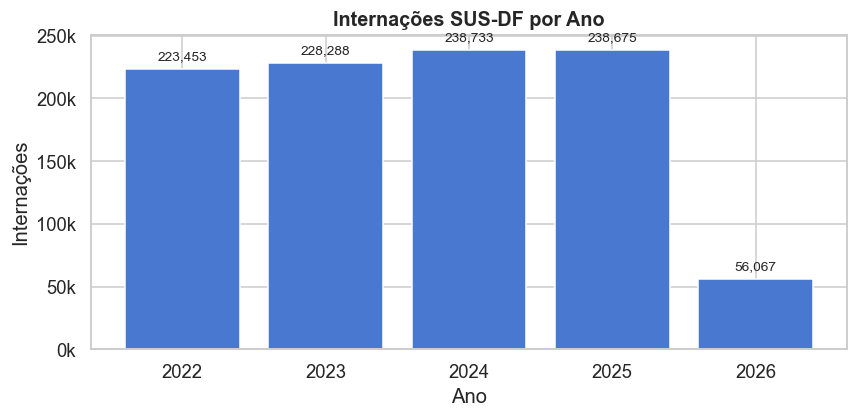


 ano internacoes
2022     223,453
2023     228,288
2024     238,733
2025     238,675
2026      56,067


In [7]:
vol_ano = df.groupby('ano')['qtd_aih'].sum().reset_index()
vol_ano.columns = ['ano', 'internacoes']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(vol_ano['ano'].astype(str), vol_ano['internacoes'],
              color=sns.color_palette('muted')[0], edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=4, fontsize=9)
ax.set_title('Internações SUS-DF por Ano', fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Internações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

print()
print(vol_ano.assign(internacoes=vol_ano['internacoes'].apply(lambda x: f'{x:,.0f}')).to_string(index=False))

#### 3.2 — Tendência mensal (série temporal)

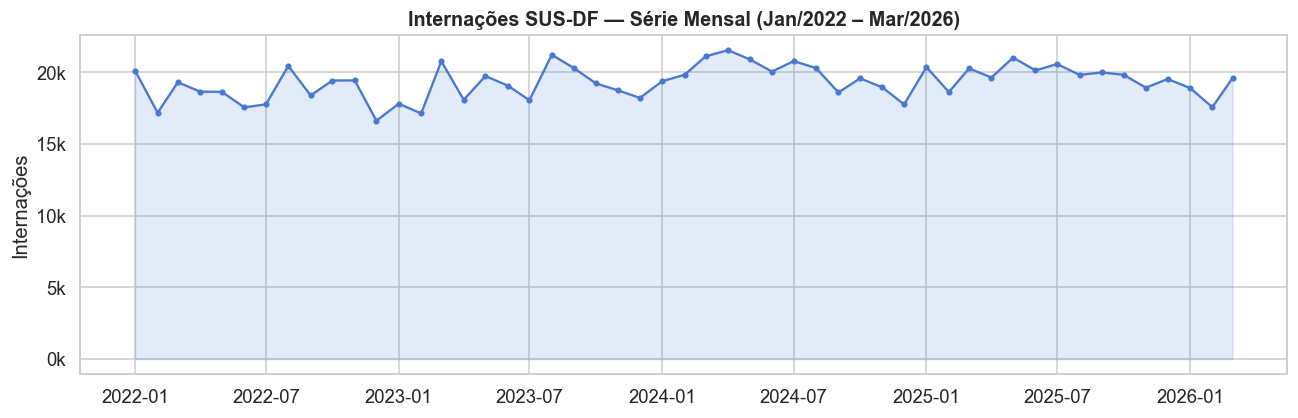

In [8]:
serie = df.groupby(['ano', 'mes'])['qtd_aih'].sum().reset_index()
serie['data'] = pd.to_datetime(serie.assign(dia=1)[['ano', 'mes', 'dia']].rename(
    columns={'ano':'year','mes':'month','dia':'day'}))
serie = serie.sort_values('data')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie['data'], serie['qtd_aih'], marker='o', markersize=3,
        linewidth=1.5, color=sns.color_palette('muted')[0])
ax.fill_between(serie['data'], serie['qtd_aih'], alpha=0.15,
                color=sns.color_palette('muted')[0])
ax.set_title('Internações SUS-DF — Série Mensal (Jan/2022 – Mar/2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Internações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

#### 3.3 — Sazonalidade mensal (média histórica por mês)

> **Nota metodológica:** `qtd_aih = 1` em cada linha. Para capturar sazonalidade real,
> primeiro somamos as internações por `(ano, mês)` para obter o volume mensal de cada
> competência, e depois calculamos a média entre os anos. Fazer `.mean()` direto no campo
> constante retornaria 1.0 para todos os meses.

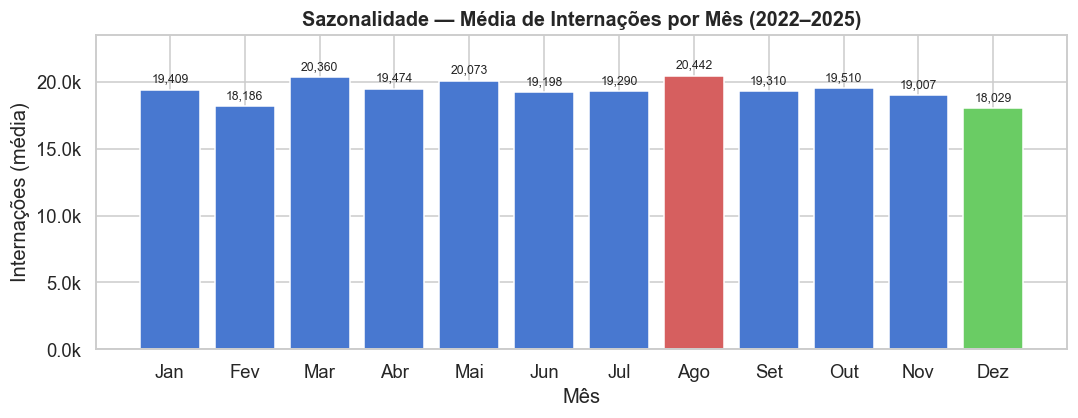


Pico: Ago (20,442 internações em média)
Vale: Dez (18,029 internações em média)

mes_nome media_internacoes
     Jan            19,409
     Fev            18,186
     Mar            20,360
     Abr            19,474
     Mai            20,073
     Jun            19,198
     Jul            19,290
     Ago            20,442
     Set            19,310
     Out            19,510
     Nov            19,007
     Dez            18,029


In [9]:
sazon = (
    df[df['ano'] < 2026]
    .groupby(['ano', 'mes'])['qtd_aih']
    .sum()
    .reset_index()
    .groupby('mes')['qtd_aih']
    .mean()
    .reset_index()
)

MESES = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
         7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
sazon['mes_nome'] = sazon['mes'].map(MESES)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [sns.color_palette('muted')[3] if v == sazon['qtd_aih'].max()
          else sns.color_palette('muted')[2] if v == sazon['qtd_aih'].min()
          else sns.color_palette('muted')[0]
          for v in sazon['qtd_aih']]
bars = ax.bar(sazon['mes_nome'], sazon['qtd_aih'], color=colors, edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=3, fontsize=8)
ax.set_title('Sazonalidade — Média de Internações por Mês (2022–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Internações (média)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}k'))
ax.set_ylim(0, sazon['qtd_aih'].max() * 1.15)
plt.tight_layout()
plt.show()

print()
print('Pico:', sazon.loc[sazon["qtd_aih"].idxmax(), "mes_nome"], f"({sazon["qtd_aih"].max():,.0f} internações em média)")
print('Vale:', sazon.loc[sazon["qtd_aih"].idxmin(), "mes_nome"], f"({sazon["qtd_aih"].min():,.0f} internações em média)")
print()
print(sazon[['mes_nome','qtd_aih']].rename(columns={'qtd_aih':'media_internacoes'}).assign(
    media_internacoes=sazon['qtd_aih'].apply(lambda x: f'{x:,.0f}')).to_string(index=False))

## 4. Perfil Epidemiológico

Quem são as populações que mais utilizam o SUS-DF?

#### 4.1 — Distribuição por Sexo

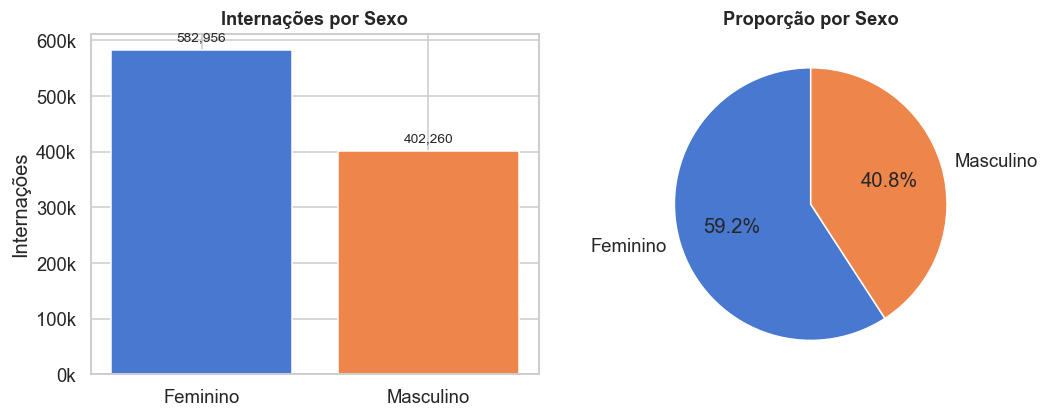


     sexo qtd_aih
 Feminino 582,956
Masculino 402,260


In [10]:
por_sexo = df.groupby('sexo')['qtd_aih'].sum().reset_index()
por_sexo = por_sexo.sort_values('qtd_aih', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Barras
bars = ax1.bar(por_sexo['sexo'], por_sexo['qtd_aih'],
               color=sns.color_palette('muted')[:len(por_sexo)], edgecolor='white')
ax1.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=4, fontsize=9)
ax1.set_title('Internações por Sexo', fontsize=12, fontweight='bold')
ax1.set_ylabel('Internações')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Pizza
wedges, texts, autotexts = ax2.pie(
    por_sexo['qtd_aih'], labels=por_sexo['sexo'],
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('muted')[:len(por_sexo)])
ax2.set_title('Proporção por Sexo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print()
print(por_sexo.assign(qtd_aih=por_sexo['qtd_aih'].apply(lambda x: f'{x:,.0f}')).to_string(index=False))

#### 4.2 — Distribuição por Faixa Etária

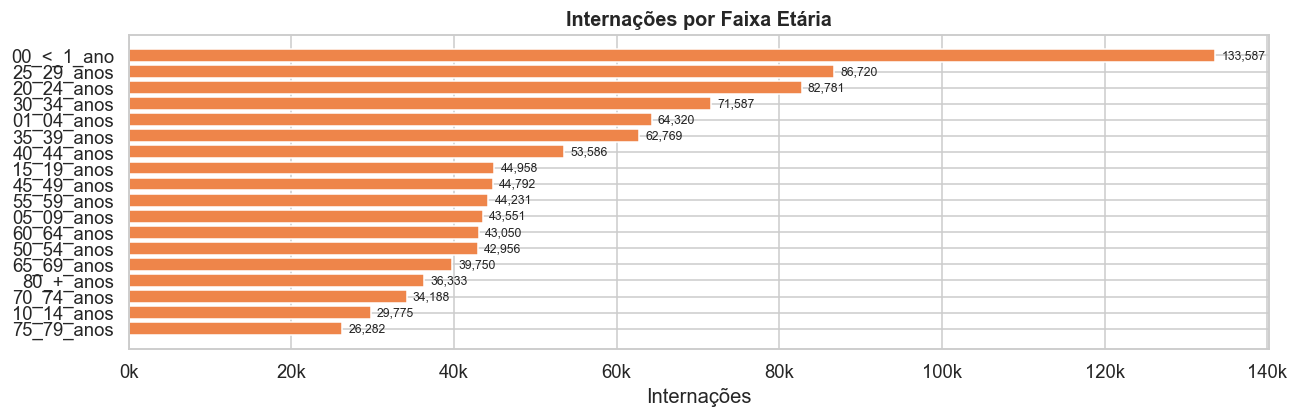

In [11]:
por_faixa = (df.groupby('faixa_etaria')['qtd_aih']
    .sum().reset_index()
    .sort_values('qtd_aih', ascending=False))

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(por_faixa['faixa_etaria'], por_faixa['qtd_aih'],
               color=sns.color_palette('muted')[1], edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=4, fontsize=8)
ax.set_title('Internações por Faixa Etária', fontsize=13, fontweight='bold')
ax.set_xlabel('Internações')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### 4.3 — Top 10 Grupos CID (causas de internação)

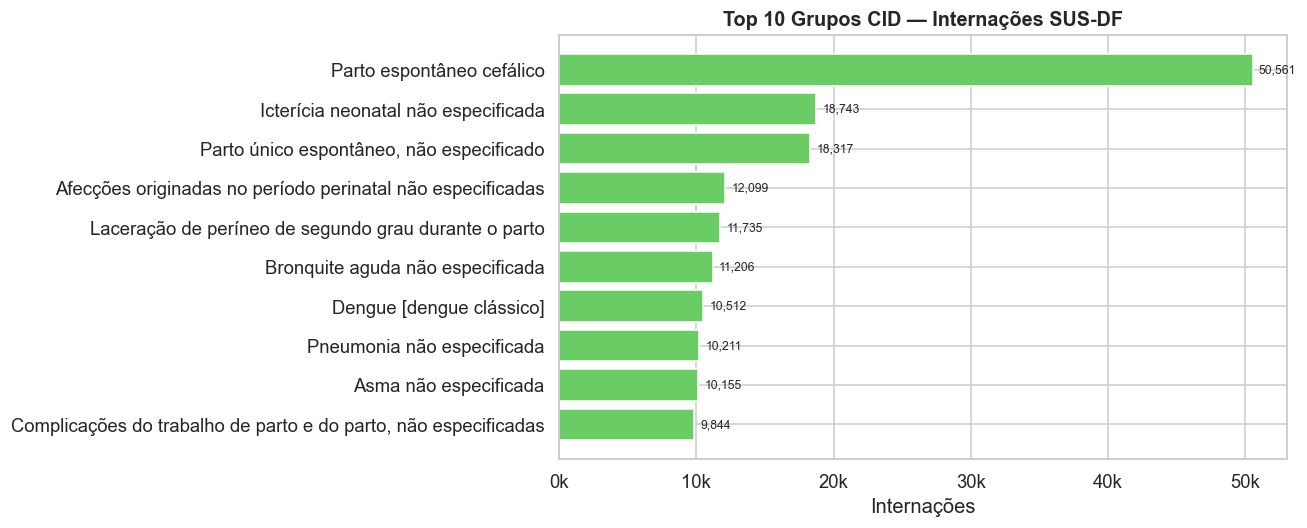

In [12]:
top_cid = (df.groupby('cid_principal')['qtd_aih']
    .sum().reset_index()
    .nlargest(10, 'qtd_aih'))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_cid['cid_principal'], top_cid['qtd_aih'],
               color=sns.color_palette('muted')[2], edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=4, fontsize=8)
ax.set_title('Top 10 Grupos CID — Internações SUS-DF', fontsize=13, fontweight='bold')
ax.set_xlabel('Internações')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Análise Geográfica — Regiões Administrativas

Quais RAs concentram mais internações?

#### 5.1 — Top 15 RAs de residência do paciente

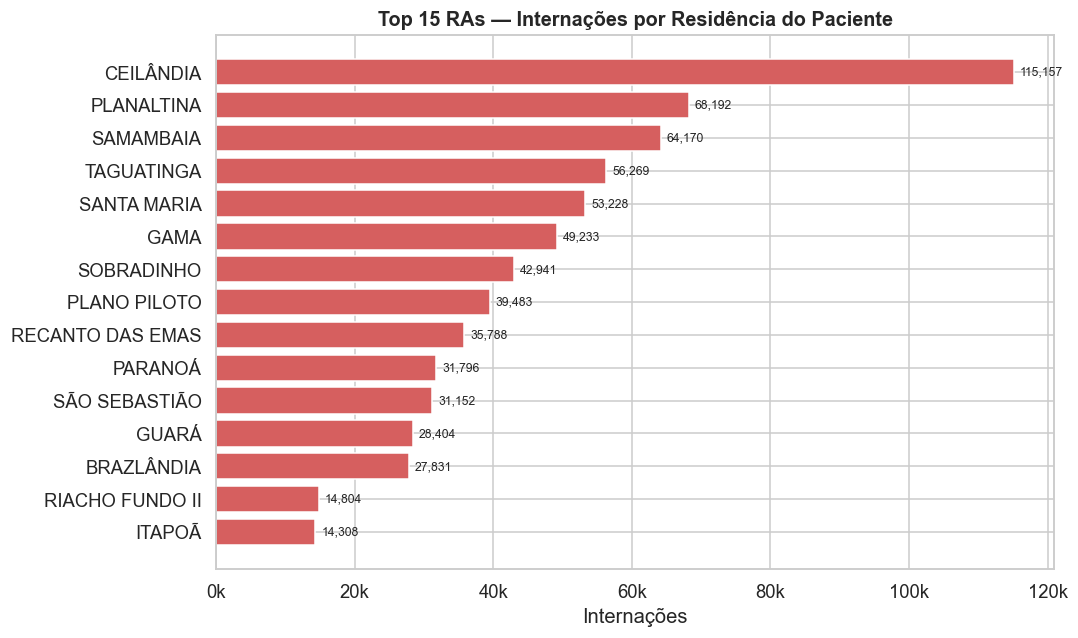

In [13]:
top_ra = (df.dropna(subset=['ra_norm'])
    .groupby('ra_norm')['qtd_aih']
    .sum().reset_index()
    .nlargest(15, 'qtd_aih'))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_ra['ra_norm'], top_ra['qtd_aih'],
               color=sns.color_palette('muted')[3], edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=4, fontsize=8)
ax.set_title('Top 15 RAs — Internações por Residência do Paciente', fontsize=13, fontweight='bold')
ax.set_xlabel('Internações')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### 5.2 — Internações com RA nula (pacientes de fora do DF)

In [14]:
nulos_ra = df['ra_residencia'].isnull().sum()
total = len(df)
print(f'RA nula: {nulos_ra:,} internações ({nulos_ra/total*100:.1f}%)')
print()
print('Top municípios de residência (excluindo DF):')
fora_df = df[df['ra_residencia'].isnull()]
print(fora_df['municipio_residencia'].value_counts().head(10).to_string())

RA nula: 208,810 internações (21.2%)

Top municípios de residência (excluindo DF):
municipio_residencia
VALPARAÍSO DE GOIÁS            37081
LUZIÂNIA                       34060
ÁGUAS LINDAS DE GOIÁS          34018
NOVO GAMA                      26320
CIDADE OCIDENTAL               17164
PLANALTINA                     11114
SANTO ANTÔNIO DO DESCOBERTO     9508
FORMOSA                         4989
PADRE BERNARDO                  4086
CRISTALINA                      4060


## 6. Análise Financeira e de Complexidade

Valor total das internações e distribuição por tipo de financiamento.

#### 6.1 — Valor total por ano

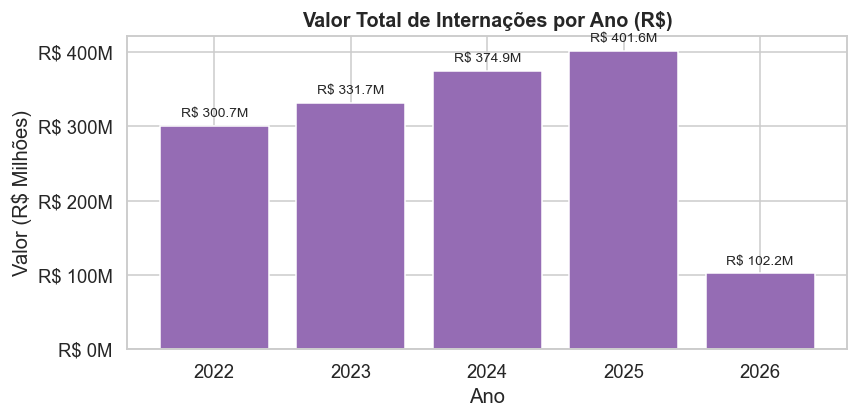

In [15]:
val_ano = df.groupby('ano')['valor_total'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(val_ano['ano'].astype(str), val_ano['valor_total'],
              color=sns.color_palette('muted')[4], edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'R$ {x/1e6:.1f}M', padding=4, fontsize=9)
ax.set_title('Valor Total de Internações por Ano (R$)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Valor (R$ Milhões)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

#### 6.2 — Distribuição por tipo de financiamento

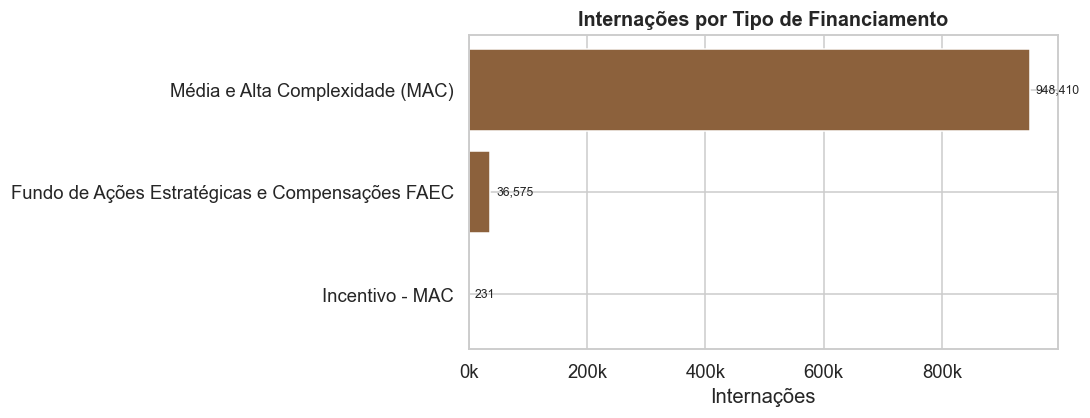

In [16]:
por_financ = (df.groupby('tipo_financiamento')['qtd_aih']
    .sum().reset_index()
    .sort_values('qtd_aih', ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(por_financ['tipo_financiamento'], por_financ['qtd_aih'],
               color=sns.color_palette('muted')[5 % len(sns.color_palette('muted'))], edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=4, fontsize=8)
ax.set_title('Internações por Tipo de Financiamento', fontsize=13, fontweight='bold')
ax.set_xlabel('Internações')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. KPIs de Evolução (YoY / Comparação de Períodos)

Comparações anuais para identificar melhora ou piora na saúde pública do DF.

In [17]:
df['obito_bin'] = (df['obitos'] == 'Com óbito').astype(int)

In [18]:
# Apenas anos completos (2022–2025)
kpi = (df[df['ano'].between(2022, 2025)]
    .groupby('ano')
    .agg(
        internacoes       = ('qtd_aih', 'sum'),
        valor_total       = ('valor_total', 'sum'),
        media_diarias     = ('diarias', 'mean'),
        media_diarias_uti = ('diarias_uti', 'mean'),
        obitos            = ('obito_bin', 'sum'),
    )
    .reset_index())

kpi['yoy_internacoes'] = kpi['internacoes'].pct_change() * 100
kpi['yoy_valor']       = kpi['valor_total'].pct_change() * 100
kpi['yoy_obitos']      = kpi['obitos'].pct_change() * 100
kpi['taxa_obito_pct']  = kpi['obitos'] / kpi['internacoes'] * 100

print('=== KPIs Anuais ===')
display_kpi = kpi.copy()
display_kpi['internacoes']   = display_kpi['internacoes'].apply(lambda x: f'{x:,.0f}')
display_kpi['valor_total']   = display_kpi['valor_total'].apply(lambda x: f'R$ {x:,.0f}')
display_kpi['obitos']        = display_kpi['obitos'].apply(lambda x: f'{x:,.0f}')
display_kpi['yoy_internacoes'] = display_kpi['yoy_internacoes'].apply(lambda x: f'{x:+.1f}%' if pd.notna(x) else '—')
display_kpi['yoy_valor']       = display_kpi['yoy_valor'].apply(lambda x: f'{x:+.1f}%' if pd.notna(x) else '—')
display_kpi['taxa_obito_pct']  = display_kpi['taxa_obito_pct'].apply(lambda x: f'{x:.3f}%')
print(display_kpi.to_string(index=False))

=== KPIs Anuais ===
 ano internacoes    valor_total  media_diarias  media_diarias_uti obitos yoy_internacoes yoy_valor  yoy_obitos taxa_obito_pct
2022     223,453 R$ 300,738,419           5.39               0.52  7,119               —         —         NaN         3.186%
2023     228,288 R$ 331,685,620           5.39               0.57  6,954           +2.2%    +10.3%       -2.32         3.046%
2024     238,733 R$ 374,885,739           5.24               0.65  7,171           +4.6%    +13.0%        3.12         3.004%
2025     238,675 R$ 401,614,294           5.29               0.69  7,063           -0.0%     +7.1%       -1.51         2.959%


#### 7.1 — Gráfico YoY: internações e taxa de óbito

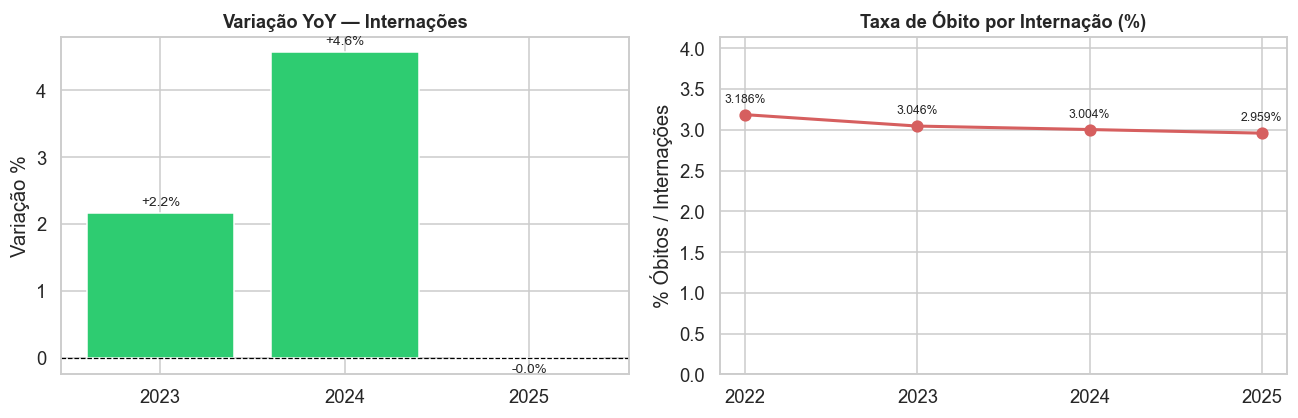

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

anos_str = kpi['ano'].astype(str)

# Internações YoY
yoy = kpi.dropna(subset=['yoy_internacoes'])
colors_yoy = ['#2ecc71' if v >= 0 else '#e74c3c' for v in yoy['yoy_internacoes']]
bars = ax1.bar(yoy['ano'].astype(str), yoy['yoy_internacoes'], color=colors_yoy, edgecolor='white')
ax1.bar_label(bars, fmt=lambda x: f'{x:+.1f}%', padding=3, fontsize=9)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Variação YoY — Internações', fontsize=12, fontweight='bold')
ax1.set_ylabel('Variação %')

# Taxa de óbito
ax2.plot(anos_str, kpi['taxa_obito_pct'], marker='o', linewidth=2,
         color=sns.color_palette('muted')[3], markersize=7)
for i, (x, y) in enumerate(zip(anos_str, kpi['taxa_obito_pct'])):
    ax2.annotate(f'{y:.3f}%', (x, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax2.set_title('Taxa de Óbito por Internação (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('% Óbitos / Internações')
ax2.set_ylim(0, kpi['taxa_obito_pct'].max() * 1.3)

plt.tight_layout()
plt.show()

## 8. Óbitos e UTI — Populações em Maior Risco

Análise focada em óbitos e uso de UTI para identificar grupos mais vulneráveis.

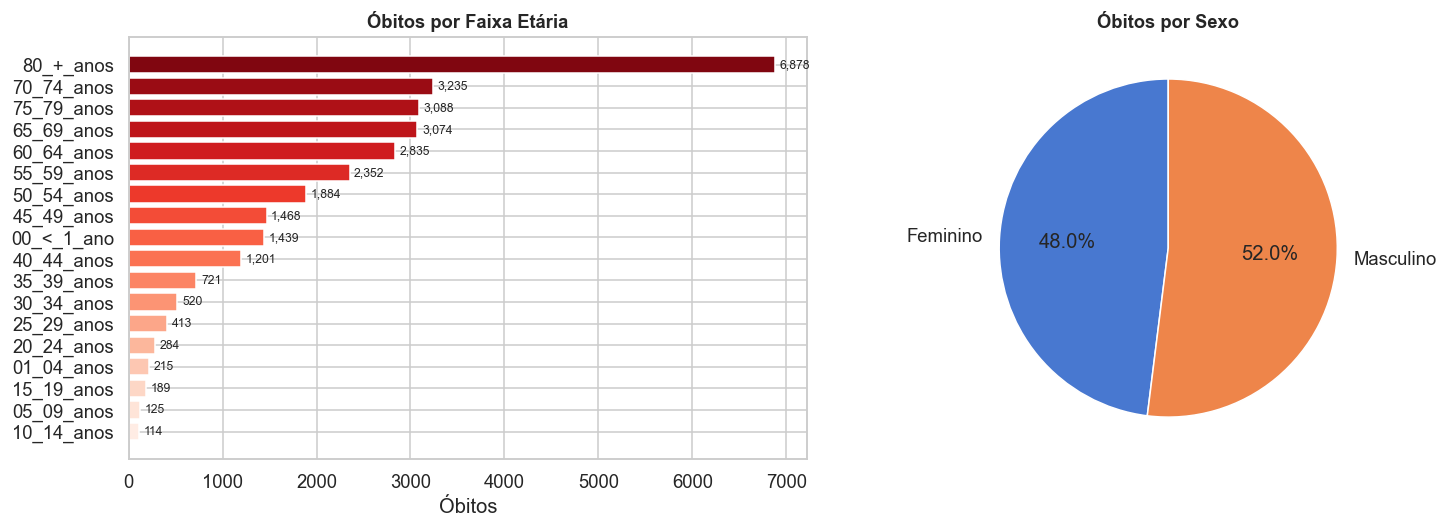

In [20]:
# Óbitos por faixa etária
obitos_faixa = (df[df['obito_bin'] > 0]
    .groupby('faixa_etaria')['obito_bin']
    .sum().reset_index()
    .sort_values('obito_bin', ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Óbitos por faixa etária
bars1 = ax1.barh(obitos_faixa['faixa_etaria'], obitos_faixa['obito_bin'],
                  color=sns.color_palette('Reds_r', len(obitos_faixa)), edgecolor='white')
ax1.bar_label(bars1, fmt=lambda x: f'{x:,.0f}', padding=3, fontsize=8)
ax1.set_title('Óbitos por Faixa Etária', fontsize=12, fontweight='bold')
ax1.set_xlabel('Óbitos')
ax1.invert_yaxis()

# Óbitos por sexo
obitos_sexo = df[df['obito_bin'] > 0].groupby('sexo')['obito_bin'].sum().reset_index()
wedges, texts, autotexts = ax2.pie(
    obitos_sexo['obito_bin'], labels=obitos_sexo['sexo'],
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('muted')[:len(obitos_sexo)])
ax2.set_title('Óbitos por Sexo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Uso de UTI
uti = df[df['diarias_uti'] > 0]
print(f'Internações com UTI: {len(uti):,} ({len(uti)/len(df)*100:.1f}% do total)')
print()
print('Diárias UTI por faixa etária:')
print(uti.groupby('faixa_etaria')['diarias_uti'].agg(['sum','mean'])
    .rename(columns={'sum':'total_diarias','mean':'media_diarias'})
    .sort_values('total_diarias', ascending=False)
    .assign(total_diarias=lambda d: d['total_diarias'].apply(lambda x: f'{x:,.0f}'),
            media_diarias=lambda d: d['media_diarias'].apply(lambda x: f'{x:.1f}'))
    .to_string())

Internações com UTI: 64,062 (6.5% do total)

Diárias UTI por faixa etária:
             total_diarias media_diarias
faixa_etaria                            
00_<_1_ano         148,542          12.3
65_69_anos          46,647           9.8
60_64_anos          44,771           9.3
80_+_anos           43,557          10.3
70_74_anos          43,286           9.9
55_59_anos          41,227           9.1
75_79_anos          36,116          10.4
50_54_anos          34,290           9.1
01_04_anos          27,230           6.9
45_49_anos          27,207           8.6
40_44_anos          24,831           9.2
35_39_anos          17,869           8.3
30_34_anos          13,650           7.8
25_29_anos          13,573           7.8
05_09_anos          12,863           5.9
20_24_anos          11,409           7.6
10_14_anos           9,975           6.3
15_19_anos           9,926           7.2


## 9. Resumo

Síntese dos principais achados para orientação de políticas públicas de saúde no DF.

* **Volume total de internações (2022–2025): 929,149**
* **Valor total gasto: R$ 1,408,924,072**
* **Óbitos registrados: 28,307 (3.05%)**

TOP 3 grupos CID (causas):
   1. Procedimentos Clínicos: 664,459 internações
   2. Procedimentos Cirúrgicos: 311,226 internações
   3. Transplantes de Orgãos, Tecidos e Células: 7,727 internações

TOP 3 RAs com mais internações:
   1. CEILÂNDIA: 115,157 internações
   2. PLANALTINA: 68,192 internações
   3. SAMAMBAIA: 64,170 internações

Sazonalidade: agosto é o mês de pico histórico; dezembro é o mês com menor volume.

Pontos de atenção em políticas públicas:
   * Alta concentração de óbitos em idosos
   * Entorno metropolitano sem RA (21% das internações sem RA mapeada)
   * UTI concentrada em grupos etários extremos (crianças e idosos)
   * Tendência de crescimento de valor/internação